In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data/hardware_reports/results_combined.csv')


/tmp/ipykernel_195796/546849350.py:1: DtypeWarning: Columns (7,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/hardware_reports/results_combined.csv')


In [4]:
df.columns

Index(['job_id', 'gpu_name', 'gpu_id', 'Start Time', 'End Time',
       'Total Execution Time (sec)', 'No. of Processes',
       'Energy Consumed (Joules)', 'Max GPU Memory Used (bytes)',
       'Single Bit ECC Errors', 'Double Bit ECC Errors',
       'PCIe Replay Warnings', 'Critical XID Errors', 'Overall Health',
       'XID (Hr:Min:Sec since start)', 'Graphics Process Utilization',
       'Unnamed: 16', '_source_file', 'PowerUsage(Watts)_Avg',
       'PowerUsage(Watts)_Max', 'PowerUsage(Watts)_Min', 'SMClock(MHz)_Avg',
       'SMClock(MHz)_Max', 'SMClock(MHz)_Min', 'MemoryClock(MHz)_Avg',
       'MemoryClock(MHz)_Max', 'MemoryClock(MHz)_Min', 'SMUtilization(%)_Avg',
       'SMUtilization(%)_Max', 'SMUtilization(%)_Min',
       'MemoryUtilization(%)_Avg', 'MemoryUtilization(%)_Max',
       'MemoryUtilization(%)_Min', 'PCIeRxBandwidth(megabytes)_Avg',
       'PCIeRxBandwidth(megabytes)_Max', 'PCIeRxBandwidth(megabytes)_Min',
       'PCIeTxBandwidth(megabytes)_Avg', 'PCIeTxBandwidth(me

In [5]:
df['count'] = 1
df.groupby(["job_id", "ComputeProcess_pid"])["count"].sum().reset_index()["count"].max()

np.int64(8)

# Preliminary

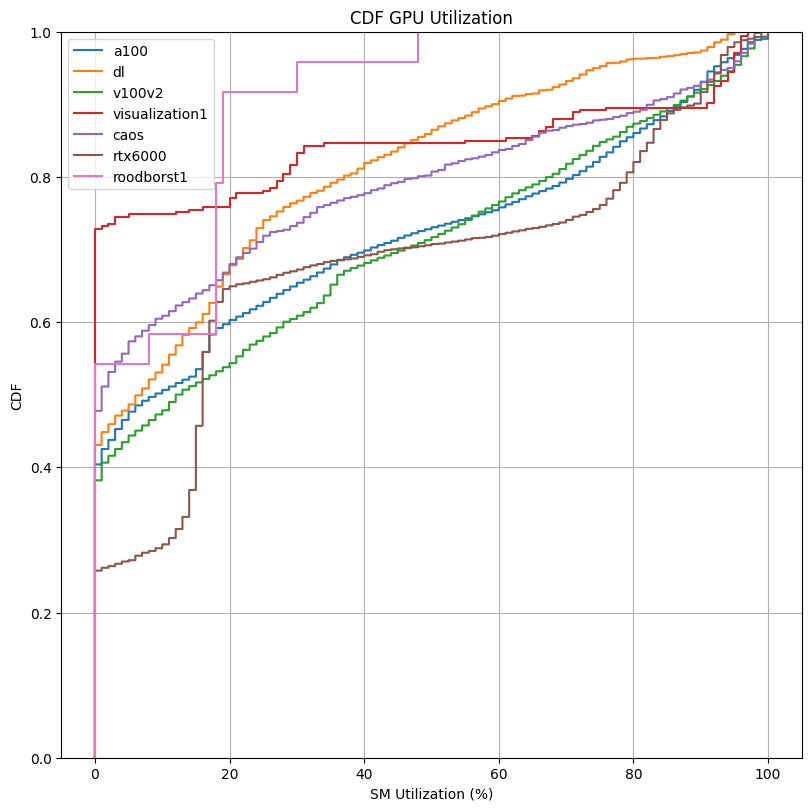

In [6]:
target_columns = ['job_id', 'gpu_name', 'gpu_id', 'Start Time', 'End Time',
       'Total Execution Time (sec)', 'No. of Processes',
       'Energy Consumed (Joules)', 'Max GPU Memory Used (bytes)',
       'Single Bit ECC Errors', 'Double Bit ECC Errors',
       'PCIe Replay Warnings', 'Critical XID Errors', 'Overall Health',
       'XID (Hr:Min:Sec since start)', 'Graphics Process Utilization',
       'Unnamed: 16', '_source_file', 'PowerUsage(Watts)_Avg',
       'PowerUsage(Watts)_Max', 'PowerUsage(Watts)_Min', 'SMClock(MHz)_Avg',
       'SMClock(MHz)_Max', 'SMClock(MHz)_Min', 'MemoryClock(MHz)_Avg',
       'MemoryClock(MHz)_Max', 'MemoryClock(MHz)_Min', 'SMUtilization(%)_Avg',
       'SMUtilization(%)_Max', 'SMUtilization(%)_Min',
       'MemoryUtilization(%)_Avg', 'MemoryUtilization(%)_Max',
       'MemoryUtilization(%)_Min', 'PCIeRxBandwidth(megabytes)_Avg',
       'PCIeRxBandwidth(megabytes)_Max', 'PCIeRxBandwidth(megabytes)_Min',
       'PCIeTxBandwidth(megabytes)_Avg', 'PCIeTxBandwidth(megabytes)_Max',
       'PCIeTxBandwidth(megabytes)_Min']

df = df[target_columns]
# Drop rows of multiple processes related to the same job, as they will have the same GPU utilization data
df = df.drop_duplicates()
df['gpu_name'] = df['gpu_name'].apply(lambda x: x.split('gpu')[0])
gpus = df['gpu_name'].drop_duplicates()

fig = plt.figure(figsize=(8, 8), layout="constrained")
axs = fig.subplots(1, 1, sharex=False, sharey=True)
axs.set_title('CDF GPU Utilization')
axs.set_xlabel('SM Utilization (%)')
axs.set_ylabel('CDF')
for g in gpus:
    snap = df[df['gpu_name'] == g]
    snap = snap.dropna(subset=['SMUtilization(%)_Avg'])
    snap = snap[snap['SMUtilization(%)_Avg'] <= 100]

    data = snap['SMUtilization(%)_Avg'].to_numpy()
    axs.ecdf(data, label=g)

plt.legend()
plt.grid()


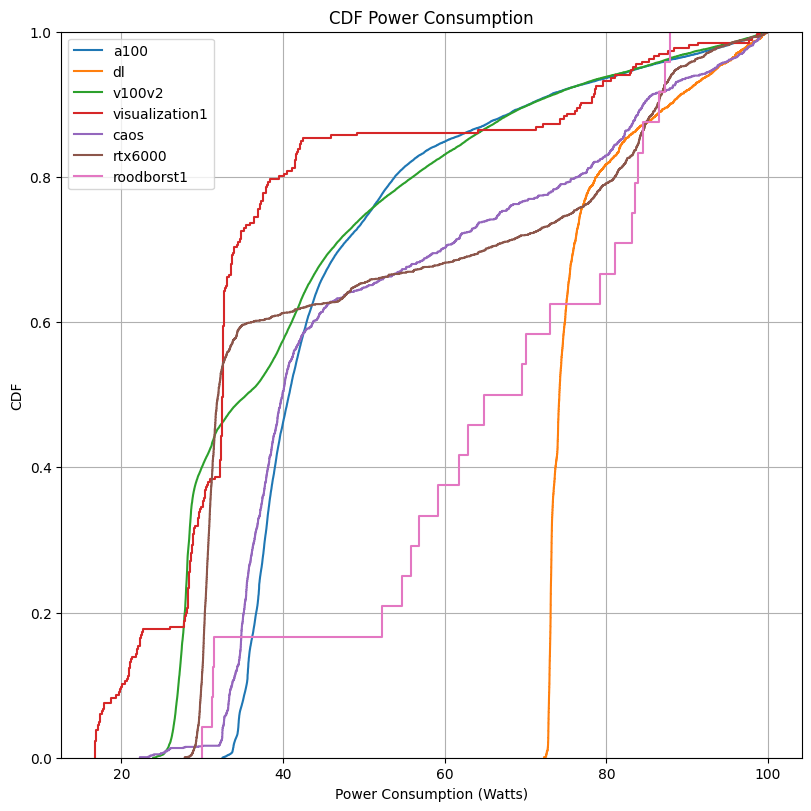

In [7]:
fig = plt.figure(figsize=(8, 8), layout="constrained")
axs = fig.subplots(1, 1, sharex=False, sharey=True)
axs.set_title('CDF Power Consumption')
axs.set_xlabel('Power Consumption (Watts)')
axs.set_ylabel('CDF')
for g in gpus:
    snap = df[df['gpu_name'] == g]
    snap = snap.dropna(subset=['PowerUsage(Watts)_Avg'])
    snap = snap[snap['PowerUsage(Watts)_Avg'] <= 100]

    data = snap['PowerUsage(Watts)_Avg'].to_numpy()
    axs.ecdf(data, label=g)

plt.legend()
plt.grid()


# Case Study

In [3]:
df = pd.read_csv("./june_to_sept.csv")


/tmp/ipykernel_207634/2180691115.py:1: DtypeWarning: Columns (16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./june_to_sept.csv")
